# **Taller 2 - Diseño de Dashboard Analítico**

> ### Maestria en Ciencia de Datos y Analítica
> ### Visualización de Datos
> #### Sara Rendon, Yeison Londoño, Heider Zapata, Kelly Enriquez


## **Contexto del problema**

Dataset: eCommerce Behavior Data (REES46, Oct 2019)

Las plataformas de e-commerce enfrentan un reto estructural: la gran mayoría de 
los usuarios que visitan un producto nunca llegan a comprarlo. Las tasas de 
conversión promedio de la industria oscilan entre el 1% y el 3%, lo que significa 
que por cada 100 visitas, 97 se van sin generar valor.

Este notebook documenta el proceso completo de análisis: desde la exploración 
inicial de los datos hasta la construcción de un argumento visual aclaratorio 
orientado a la toma de decisiones de negocio.

## **Pregunta de Negocio**

> **¿Qué patrones de comportamiento en el e-commerce revelan oportunidades para intervenir con incentivos y aumentar la conversión?**

Entender dónde, cuándo y por qué los usuarios no completan una compra es el primer paso para identificar a quién vale la pena incentivar. Esa pregunta paraguas se descompone en **tres preguntas de negocio operativas** que guían el análisis y, después, el dashboard:

| # | Pregunta de negocio | Se responde en |
|---|---------------------|----------------|
| **PN1** | **¿Dónde perdemos conversión y cuánto vale recuperarla?** | Funnel por unidad (4.1), abandono de carrito (4.5), premio en \$ (4.8a), marca (4.8c) |
| **PN2** | **¿Quiénes son los clientes valiosos y cómo retenerlos?** | Recurrencia por ocasión (4.6), timing de recompra (4.8b) |
| **PN3** | **¿Cuándo y con qué activar el incentivo?** | Patrón horario e intensidad (4.3), velocidad de decisión (4.7), precio-no-es-freno (4.2) |

## **Hallazgo central**

> **El negocio deja dinero sobre la mesa en electrónica.** Hay dos momentos para capturarlo, ambos concentrados en la misma categoría:

- **(A) Antes de comprar — recuperar carritos abandonados.** El abandono real es del **32,4%** y se concentra en electrónica/electrodomésticos (electronics = 67% del abandono). Son **~\$2,08 M** en juego solo en electronics (82% del premio total de \$2,53 M), con Apple y Samsung al frente. El comprador con intención decide en **minutos** (mediana 2,2 min) → incentivo **inmediato/en pantalla**, en la **franja matutina** (la mañana convierte ~2× por visita).
- **(B) Después de comprar — retener al núcleo recurrente.** El **31,7%** de los compradores son recurrentes y concentran el **69% del revenue** (ticket ~5× mayor: \$1.411 vs \$293). La 2ª compra llega en mediana **1,8 días** y el **85,5%** es en la misma categoría → **nudge de recompra a 24–72 h** en su categoría.

> Una historia, dos palancas (conversión + retención), una sola categoría protagonista: **electrónica**.

## **Generación de la muestra**

> ### ⚠️ Cambio metodológico respecto a la versión anterior
>
> La muestra de trabajo de este notebook **cambió**. Se documentan los dos procesos
> para dejar trazabilidad:
>
> **1. Muestreo original (descartado).** Se generó con `USING SAMPLE 500000` sobre el
> crudo `2019-Oct.csv` = **muestreo uniforme por evento**. Al elegir eventos sueltos al
> azar, **rompe sesiones y usuarios**: una sesión puede conservar el `cart` y perder su
> `purchase`, o un usuario recurrente perder parte de su historial. Esto **sesga al alza**
> los hallazgos de nivel sesión/usuario (abandono de carrito, recurrencia, velocidad de
> decisión). Las celdas comentadas a continuación se conservan como **registro histórico**
> de ese proceso; **no se ejecutan**.
>
> **2. Muestreo actual (vigente): por usuario (cluster sampling).** Se eligen `user_id`
> al azar y se traen **todos** sus eventos, preservando sesiones completas e historial de
> compra. Es un **muestreo aleatorio simple de usuarios** (no se sobre-muestrean
> compradores → no sesga las tasas del funnel), con **semilla fija** para reproducibilidad.
> Está implementado en `src/sampling.py` (Fase 0) y se corre una sola vez.
>
> **Calibración y resultado (Fase 0, semilla 42).** El crudo tiene 42.448.764 eventos /
> 3.022.290 usuarios (≈14,05 eventos/usuario); para apuntar a ~1.000.000 de eventos se
> muestrearon **71.199 usuarios**. La muestra resultante (antes de limpieza) tiene
> **982.106 eventos** sobre **214.759 sesiones**, con la distribución natural de eventos:
> `view` 96,11 % · `cart` 2,17 % · `purchase` 1,72 % (16.925 compras). Se guarda en
> `data/processed/muestra_usuarios.parquet`.


In [ ]:
#pip install duckdb

In [ ]:
# import duckdb
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

In [ ]:
# Instalar la librería gdown si es necesario
# !pip install --upgrade gdown

# import gdown
# import os

# # 2. Configuración del ID del archivo y la URL de descarga
# FILE_ID = '1kDasOXgXimvPn2Shu3wgZymbqj4_8pDc'  
# url = f'https://drive.google.com/uc?id={FILE_ID}'
# output_file = '2019-Oct.csv'

# # 3. Descargar el archivo solo si no existe localmente (para evitar descargas repetidas)
# if not os.path.exists(output_file):
#     print("Iniciando la descarga del dataset de 5GB desde Google Drive...")
#     # gdown se encarga de gestionar la advertencia de tamaño de Google
#     gdown.download(url, output_file, quiet=False)
#     print("¡Descarga completada!")
# else:
#     print("El archivo ya existe en el entorno local.")

**[Proceso original — descartado]** El código a continuación realizaba un muestreo
**uniforme por evento** (`USING SAMPLE 500000`) sobre `2019-Oct.csv`, buscando 500.000
filas. Es el muestreo que se reemplazó por el muestreo por usuario (ver nota arriba). Se
conserva comentado solo como referencia.


In [ ]:
# con = duckdb.connect()

# # Query para traer:
# # 1. El 100% de los eventos 'purchase' y 'cart'
# # 2. Solo un 2% de los eventos 'view' para no saturar la memoria
# query = """
#     SELECT * FROM read_csv_auto('2019-Oct.csv') 
#     USING SAMPLE 500000;
# """

# # Ejecutamos y guardamos en un DataFrame de Pandas
# df_muestra = con.execute(query).df()

# print(f"Tamaño de la muestra: {len(df_muestra)} filas")
# print(df_muestra['event_type'].value_counts())

**[Resultado del muestreo original — descartado]** Salida del muestreo uniforme por evento
(500.000 registros de `2019-Oct.csv`):

- Tamaño de la muestra: 500.000 filas
- `view` 480.542 · `cart` 10.851 · `purchase` 8.607

> Nota: estas cifras NO corresponden a la muestra de trabajo actual. La muestra vigente
> (por usuario) se describe en la nota metodológica de arriba y se carga en la sección
> **Carga de Datos**.


In [ ]:
#df_muestra.to_csv('muestra_eventos.csv', index=False)

## **Carga de Datos**

Cargamos la **muestra por usuario** generada en la Fase 0 (`src/sampling.py`, semilla 42),
almacenada en `data/processed/muestra_usuarios.parquet`.

A diferencia del muestreo original (uniforme por evento), aquí se eligieron **71.199
usuarios** al azar y se trajeron **todos** sus eventos, por lo que las sesiones y el
historial de compra de cada usuario quedan **completos** — condición necesaria para que los
hallazgos de abandono (4.5), recurrencia (4.6) y velocidad de decisión (4.7) sean válidos.

La muestra trae **982.106 eventos** sobre **214.759 sesiones** (cifras antes de limpieza; la
limpieza de la sección 2 ajusta estos totales).


In [ ]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente para toda la exploración
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

# ── Localizar la raíz del repo (fuente única de rutas: config.py) ─────────────
# El notebook vive en notebooks/, así que subimos desde el cwd hasta encontrar config.py.
for _cand in [Path.cwd(), *Path.cwd().parents]:
    if (_cand / "config.py").exists():
        ROOT = _cand
        break
else:
    raise FileNotFoundError("No se encontró config.py subiendo desde el directorio actual.")
sys.path.insert(0, str(ROOT))
import config  # SEED, rutas, TARGET_EVENTS
config.FIGURES.mkdir(parents=True, exist_ok=True)  # asegura outputs/figures/ para guardar gráficas

# ── Carga de la muestra POR USUARIO (Fase 0) ─────────────────────────────────
df_muestra = pd.read_parquet(config.SAMPLE_PARQUET)

# event_time viene del crudo como texto con sufijo 'UTC'; lo normalizamos a datetime
# tz-naive (todo el dataset es UTC) para habilitar hour/day_of_week y los deltas de tiempo.
df_muestra['event_time'] = pd.to_datetime(df_muestra['event_time'], utc=True).dt.tz_localize(None)

# ── Verificación rápida ───────────────────────────────────────────────────────
print(f"Fuente          : {config.SAMPLE_PARQUET}")
print(f"Dataset cargado : {df_muestra.shape[0]:,} filas × {df_muestra.shape[1]} columnas")
print(f"event_time dtype: {df_muestra['event_time'].dtype}")
print(f"Rango temporal  : {df_muestra['event_time'].min()}  →  {df_muestra['event_time'].max()}")
print(f"Usuarios únicos : {df_muestra['user_id'].nunique():,}")
print(f"Sesiones únicas : {df_muestra['user_session'].nunique():,}")
print(f"\nDistribución de eventos:")
print(df_muestra['event_type'].value_counts())


In [ ]:
df_muestra.head()

## **1. Inspección y Calidad de los Datos**

Antes de cualquier análisis, verificamos la estructura del dataset, los tipos
de datos, valores nulos y posibles inconsistencias. Este paso es fundamental
para garantizar que los hallazgos del EDA sean confiables.

> **Nota de lectura:** las gráficas de esta sección son **a nivel evento** (cada fila
> del log cuenta una vez). Sirven para calidad — detectar nulos, duplicados y precios
> anómalos —, **no** para leer conversión: como cada compra arrastra muchos `view`
> previos, la composición view/cart/purchase del log **no es un funnel**. El funnel real
> (por unidad: producto dentro de sesión) se construye en la sección **4.1**.


In [ ]:
# ── Estructura general ────────────────────────────────────────────────────────
print("=" * 55)
print("ESTRUCTURA DEL DATASET")
print("=" * 55)
print(df_muestra.info())

# ── Valores nulos ─────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("VALORES NULOS")
print("=" * 55)
missing = pd.DataFrame({
    'Nulos': df_muestra.isnull().sum(),
    'Porcentaje (%)': (df_muestra.isnull().sum() / len(df_muestra) * 100).round(2)
})
print(missing[missing['Nulos'] > 0])

# ── Duplicados ────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("DUPLICADOS")
print("=" * 55)
duplicados = df_muestra.duplicated().sum()
print(f"Filas duplicadas: {duplicados:,} ({duplicados/len(df_muestra)*100:.2f}%)")

# ── Valores únicos por columna categórica ────────────────────────────────────
print("\n" + "=" * 55)
print("VALORES ÚNICOS (columnas categóricas)")
print("=" * 55)
for col in ['event_type', 'brand', 'category_code']:
    print(f"{col}: {df_muestra[col].nunique():,} valores únicos")

# ── Rango de precios ──────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("RANGO DE PRECIOS")
print("=" * 55)
print(df_muestra['price'].describe())

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Panel de Calidad de Datos\nmuestra_usuarios.parquet (por usuario) — Oct 2019',
             fontsize=14, fontweight='bold', y=1.01)

# ── Gráfico 1 (arriba izquierda): Completitud por columna ────────────────────
completitud = (df_muestra.notnull().sum() / len(df_muestra) * 100).sort_values()
colores_comp = ['#d62728' if v < 90 else '#2ca02c' for v in completitud]

axes[0, 0].barh(completitud.index, completitud.values, color=colores_comp)
axes[0, 0].set_xlim(0, 110)
axes[0, 0].axvline(100, color='gray', linestyle='--', linewidth=0.8)
axes[0, 0].set_title('Completitud por Columna (%)', fontweight='bold')
axes[0, 0].set_xlabel('% de valores presentes')
for i, v in enumerate(completitud.values):
    axes[0, 0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# ── Gráfico 2 (arriba derecha): Composición del LOG de eventos (nivel evento) ─
# OJO: esto NO es un funnel. Cada fila = 1 evento; los view dominan por construcción
# (cada compra arrastra muchas vistas). El funnel por unidad se calcula en 4.1.
event_counts = df_muestra['event_type'].value_counts().reindex(['view', 'cart', 'purchase'])
event_pct = (event_counts / len(df_muestra) * 100).round(2)

bars = axes[0, 1].barh(event_pct.index, event_pct.values,
                        color=sns.color_palette('colorblind', 3))
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlim(0, 110)
axes[0, 1].set_title('Composición del Log de Eventos (nivel evento)', fontweight='bold')
axes[0, 1].set_xlabel('% del total de eventos (registros)')
axes[0, 1].annotate('No es el funnel: cada fila es 1 evento.\nFunnel por unidad → sección 4.1',
                    xy=(0.97, 0.05), xycoords='axes fraction', ha='right', va='bottom',
                    fontsize=8, style='italic', color='#555555')
for bar, val in zip(bars, event_pct.values):
    axes[0, 1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

# ── Gráfico 3 (abajo izquierda): Distribución de precios POR PRODUCTO ÚNICO ───
# Un precio (mediana) por product_id: evita que los productos muy vistos sobre-pesen
# el histograma (el precio NO se cuenta una vez por evento, sino una vez por producto).
precio_producto = df_muestra.groupby('product_id')['price'].median()

axes[1, 0].hist(precio_producto, bins=60, color=sns.color_palette('colorblind')[0],
                edgecolor='white', linewidth=0.4)
axes[1, 0].axvline(precio_producto.median(), color='#d62728', linestyle='--',
                   linewidth=1.5, label=f"Mediana: ${precio_producto.median():.0f}")
axes[1, 0].set_title(f'Distribución de Precios por Producto Único\n({precio_producto.size:,} productos)',
                     fontweight='bold')
axes[1, 0].set_xlabel('Precio mediano del producto (USD)')
axes[1, 0].set_ylabel('Número de productos')
axes[1, 0].legend(fontsize=9)

# ── Gráfico 4 (abajo derecha): Resumen de problemas de calidad (dinámico) ─────
problemas = {
    'category_code\nnulos': int(df_muestra['category_code'].isnull().sum()),
    'brand\nnulos':         int(df_muestra['brand'].isnull().sum()),
    'Duplicados':           int(df_muestra.duplicated().sum()),
    'Precio = $0':          int((df_muestra['price'] == 0).sum()),
}
colores_prob = sns.color_palette('colorblind', len(problemas))
barras = axes[1, 1].bar(list(problemas.keys()), list(problemas.values()), color=colores_prob)
axes[1, 1].set_title('Registros con Problemas de Calidad', fontweight='bold')
axes[1, 1].set_ylabel('Número de registros')
_offset = max(problemas.values()) * 0.01 + 1
for bar, val in zip(barras, problemas.values()):
    pct = val / len(df_muestra) * 100
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + _offset,
                    f'{val:,}\n({pct:.2f}%)', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(config.FIGURES / 'calidad_datos.png', bbox_inches='tight')
plt.show()


## **2. Limpieza de Datos**

Con base en la inspección anterior, aplicamos las siguientes decisiones:

- **Duplicados:** Se eliminan las **564 filas** duplicadas (0.06%).
- **Precios en cero:** Se eliminan — un precio de $0 no representa un evento
  de compra real y distorsionaría el análisis de conversión. (La cantidad exacta
  la reporta la celda de limpieza.)
- **`category_code` nulos (31.98%):** Se **conservan**. Es alto pero estos
  registros siguen siendo válidos para analizar el funnel general.
  Los filtraremos solo cuando el análisis requiera trabajar por categoría.
- **`brand` nulos (14.38%):** Se **conservan** por la misma razón.


In [ ]:
filas_inicio = len(df_muestra)
print(f"Filas antes de limpieza: {filas_inicio:,}")

# ── Eliminar duplicados ───────────────────────────────────────────────────────
n_dup = int(df_muestra.duplicated().sum())
df_muestra = df_muestra.drop_duplicates()

# ── Eliminar precios en cero ─────────────────────────────────────────────────
precios_cero = int((df_muestra['price'] == 0).sum())
df_muestra = df_muestra[df_muestra['price'] > 0]

filas_fin = len(df_muestra)
pct_perdido = (filas_inicio - filas_fin) / filas_inicio * 100
print(f"Filas eliminadas por duplicado: {n_dup:,}")
print(f"Filas eliminadas por precio = $0: {precios_cero:,}")
print(f"Filas después de limpieza:  {filas_fin:,}")
print(f"Total perdido: {filas_inicio - filas_fin:,} filas ({pct_perdido:.2f}%)")


> Tras la limpieza se pierde una fracción mínima de los datos (ver el porcentaje impreso
> arriba). Es un dataset sólido para trabajar.


## **3. Feature Engineering**

Derivamos nuevas variables a partir de las existentes para enriquecer el 
análisis. Todas se construyen sobre el dataset ya limpio.

- **`hour`**: Hora del evento — para analizar patrones de compra por franja horaria.
- **`day_of_week`**: Día de la semana — para identificar días de mayor conversión.
- **`date`**: Fecha sin hora — para análisis de tendencia diaria.
- **`category_main`**: Primer nivel de la jerarquía de categoría 
  (ej: `electronics.smartphone` → `electronics`).

In [ ]:
df_muestra['hour']          = df_muestra['event_time'].dt.hour
df_muestra['day_of_week']   = df_muestra['event_time'].dt.day_name()
df_muestra['date']          = df_muestra['event_time'].dt.date
df_muestra['category_main'] = df_muestra['category_code'].str.split('.').str[0]

print("Variables derivadas agregadas:")
print(f"   • hour          → {df_muestra['hour'].nunique()} valores únicos (0–23)")
print(f"   • day_of_week   → {df_muestra['day_of_week'].nunique()} días")
print(f"   • date          → {df_muestra['date'].nunique()} fechas distintas")
print(f"   • category_main → {df_muestra['category_main'].nunique()} categorías principales")
print(f"\n Vista previa:")
print(df_muestra[['event_time','hour','day_of_week','category_main']].head(5))

## **4. FASE I - Análisis Exploratorio de Datos (EDA) y Hallazgos**

### **4.1 Funnel de Conversión (por unidad)**

Construimos el funnel **por unidad = producto dentro de sesión** `(user_session, product_id)`:
cada producto que un usuario tocó en una sesión se clasifica por su **etapa más profunda**
(vista → carrito → compra) y las tasas se **encadenan**. Esto corrige el cálculo anterior,
que dividía conteos de eventos (`purchase_events / view_events`) — un cociente que **no es un
funnel de unidades** (el denominador se infla con multi-vistas y las tasas no encadenan).

La lógica vive en `src/funnel.py` (`global_funnel`, `category_funnel`), compartida con el
dashboard para que ambos reporten exactamente lo mismo.

> **Nota:** Los registros sin `category_main` se excluyen del análisis **por categoría**
> (no del funnel global).


**Gráfico izquierdo — Funnel global (unidades)**

Cada unidad es un par (sesión, producto). Contamos cuántas unidades alcanzan cada etapa
— vista → carrito → compra — y el % respecto al total de unidades. La tasa **encadenada**
carrito→compra responde la pregunta clave: de las unidades que llegan al carrito, ¿cuántas
terminan en compra?

**Gráfico derecho — Cart rate vs. conv rate por categoría**

Para cada categoría con **≥500 unidades** (para que la tasa sea representativa):
- **cart rate** = % de unidades que llegan al carrito
- **conv rate** = % de unidades que compran

La línea punteada marca la mediana de conv rate como referencia.


In [ ]:
from src.funnel import global_funnel, category_funnel

# ── Funnel global por UNIDAD (producto dentro de sesión) ──────────────────────
gf = global_funnel(df_muestra)
print("Funnel global — unidad = producto dentro de sesión")
print(f"  Unidades (producto-sesión)   : {gf['n_units']:,}")
print(f"  Llegan a carrito             : {gf['reached_cart']:,}  ({gf['cart_rate']:.2f}% de unidades)")
print(f"  Compran                      : {gf['reached_purchase']:,}  ({gf['conv_rate']:.2f}% de unidades)")
print(f"  Cart → purchase (encadenado) : {gf['cart_to_purchase']:.1f}%")
print("  Partición por etapa más profunda (suma 100%):")
for k, lbl in [('view_only', 'solo vista'), ('cart_only', 'carrito sin compra'), ('purchased', 'compra')]:
    print(f"    {lbl:20s}: {gf[k]:,}  ({gf[k] / gf['n_units'] * 100:.2f}%)")

# ── Funnel por categoría (unidad = producto-en-sesión, ≥500 unidades) ─────────
cat_funnel = category_funnel(df_muestra, min_units=500)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Funnel de Conversión por Unidad (producto dentro de sesión)',
             fontsize=14, fontweight='bold')

# --- Izquierda: funnel global acumulado ---
etapas = ['Vista', 'Carrito', 'Compra']
valores = [gf['n_units'], gf['reached_cart'], gf['reached_purchase']]
bars = axes[0].barh(etapas, valores, color=sns.color_palette('colorblind', 3))
axes[0].invert_yaxis()
axes[0].set_title('Funnel Global (unidades)', fontweight='bold')
axes[0].set_xlabel('Nº de unidades (producto-sesión)')
axes[0].set_xlim(0, gf['n_units'] * 1.18)
for bar, val in zip(bars, valores):
    pct = val / gf['n_units'] * 100
    axes[0].text(bar.get_width() + gf['n_units'] * 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}  ({pct:.1f}%)', va='center', fontsize=10)

# --- Derecha: cart_rate vs conv_rate por categoría ---
cat_sorted = cat_funnel.sort_values('conv_rate', ascending=True)
y = range(len(cat_sorted))
width = 0.4
colores_cb = sns.color_palette('colorblind', 2)
axes[1].barh([i + width / 2 for i in y], cat_sorted['cart_rate'],
             height=width, color=colores_cb[0], label='Cart rate (llega a carrito)')
axes[1].barh([i - width / 2 for i in y], cat_sorted['conv_rate'],
             height=width, color=colores_cb[1], label='Conv rate (compra)')
axes[1].set_yticks(list(y))
axes[1].set_yticklabels(cat_sorted.index)
axes[1].set_title('Cart Rate vs. Conv Rate por Categoría (%)\nunidad = producto-en-sesión · ≥500 unidades',
                  fontweight='bold')
axes[1].set_xlabel('% de unidades')
axes[1].axvline(cat_sorted['conv_rate'].median(), color='gray',
                linestyle='--', linewidth=1, label='Mediana conv rate')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(config.FIGURES / 'exploracion_01_funnel.png', bbox_inches='tight')
plt.show()

print("\nTabla de funnel por categoría (≥500 unidades), ordenada por conv_rate:")
print(cat_funnel[['units', 'reached_cart', 'purchased', 'cart_rate', 'conv_rate', 'cart_to_purchase']]
      .round(2))


**Hallazgo 1 — funnel por unidad (producto dentro de sesión)**

> **Nota sobre comparabilidad:** las tasas de abajo **no son comparables 1:1 con la versión
> anterior** del notebook. Antes el denominador eran *eventos `view`* (cociente de conteos de
> eventos); ahora es *unidades = producto dentro de sesión*. Es esperable que las conv_rate
> suban y que el ranking entre categorías cambie. Todo lo que sigue se lee sobre la nueva base.

**Global.** De 642.169 unidades (producto-sesión), el **3.61%** llega al carrito y el **2.44%**
compra. De las que llegan al carrito, **67.6%** termina comprando (≈32% abandona). Partición por
etapa más profunda: **96.39% solo vista**, **1.17% carrito sin compra**, **2.44% compra**.

**El "persuadible" (carrito sin compra) está en el volumen, no en construction.** El pool de
carritos abandonados se concentra abrumadoramente en **electronics (~5.048 unidades, ~67% del
total)** y appliances (~823); construction aporta apenas ~70. Esto **corrige** la lectura
anterior, que señalaba a construction como objetivo quirúrgico del incentivo de cierre.

**Dos problemas distintos por categoría:**
- **Cierre (llegan al carrito pero no cierran):** electronics (cart 6.12% → conv 3.92%) y
  computers (cart 2.50% → conv 1.53%, el **peor cierre**: solo 61.3%). Aquí el incentivo de cierre
  (envío gratis, urgencia) tiene sentido — y el volumen está en electronics.
- **Upstream (ni llegan al carrito):** apparel (cart 0.52%, pero **cierre 100%**), furniture
  (0.76%, cierre 87%) y accessories (0.97%). Quien llega al carrito casi siempre compra; el freno
  es de *vitrina* (imágenes, tallas, comparación), no de precio ni de cierre.

**Implicación de negocio:** segmentar la intervención. Incentivo de **cierre** donde hay carritos
abandonados en volumen (electronics, appliances) y peor cierre (computers); mejoras **upstream**
(vitrina/ficha) en apparel y furniture, donde el problema es que nunca llegan al carrito.


In [ ]:
# Slopegraph cart_rate → conv_rate por categoría (la caída entre puntos = carritos que NO
# cierran). Los datos se toman de cat_funnel (4.1), ya NO están hardcoded.
#
# NOTA (Fase II): el protagonista es PROVISIONAL. Bajo el funnel por unidad, electronics
# concentra ~67% de los carritos abandonados (≈5.000 unidades) → es la mayor oportunidad de
# incentivo de cierre. Ajusta HIGHLIGHT / CATS_SLOPE si el mensaje de la Fase II lo pide.
HIGHLIGHT = 'electronics'
CATS_SLOPE = ['electronics', 'computers', 'apparel']  # líder · peor cierre · problema upstream

sg = cat_funnel.loc[[c for c in CATS_SLOPE if c in cat_funnel.index], ['cart_rate', 'conv_rate']]

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#E0E0E0')
ax.tick_params(axis='both', which='both', length=0)
ax.set_yticks([])  # etiquetas directas en cada extremo (Data-to-Ink alto)

color_highlight = '#d62728'  # rojo para la oportunidad
color_context = '#B0B0B0'    # gris para el contexto

for cat, row in sg.iterrows():
    es_hero = (cat == HIGHLIGHT)
    color = color_highlight if es_hero else color_context
    lw = 3 if es_hero else 1.5
    ax.plot(['1. Llegada al Carrito', '2. Cierre de Compra'],
            [row['cart_rate'], row['conv_rate']],
            color=color, linewidth=lw, marker='o', markersize=8)
    ax.text(-0.05, row['cart_rate'], f"{cat.capitalize()} ({row['cart_rate']:.2f}%)",
            color=color, fontsize=11, ha='right', va='center',
            fontweight='bold' if es_hero else 'normal')
    ax.text(1.05, row['conv_rate'], f"{row['conv_rate']:.2f}%",
            color=color, fontsize=11, ha='left', va='center',
            fontweight='bold' if es_hero else 'normal')

h = sg.loc[HIGHLIGHT]
gap = h['cart_rate'] - h['conv_rate']
ax.set_title(f"La oportunidad de cierre: '{HIGHLIGHT.capitalize()}' atrae al carrito y pierde "
             f"{gap:.2f} pp al pagar",
             fontsize=15, fontweight='bold', loc='left', pad=30, color='#333333')
ax.annotate("Aquí se pierde la venta.\nEs el mayor pool de carritos abandonados\n→ máxima oportunidad de incentivo de cierre.",
            xy=(0.5, (h['cart_rate'] + h['conv_rate']) / 2), xytext=(0.5, h['conv_rate'] * 0.5),
            color='#d62728', fontsize=10, ha='center',
            arrowprops=dict(arrowstyle="->", color='#d62728', connectionstyle="arc3,rad=-0.2"))

plt.tight_layout()
plt.savefig(config.FIGURES / 'hallazgo1_slopegraph.png', bbox_inches='tight')
plt.show()


El objetivo de la gráfica es mostrar a la gerencia **dónde** concentrar el incentivo de cierre.
Bajo el funnel por unidad, ese lugar es **electronics**: aunque es la categoría más sana, su
volumen hace que la fuga carrito→compra equivalga a ~5.000 ventas perdidas — el mayor pool de
carritos recuperables. *(Protagonista provisional; se confirma al definir el mensaje en la Fase II.)*


No todos los problemas de conversión son iguales. En **apparel** el freno es de *vitrina*
(cart 0.52%, pero quien llega al carrito compra el 100%): hay que mejorar la ficha/imágenes, no
dar descuento de cierre. En **electronics** y **computers** el usuario sí arma el carrito pero
una parte se cae al pagar (computers cierra solo 61.3%): ese es el arquetipo del usuario
**"persuadible"**, donde un incentivo de cierre puede mover la aguja.


### **4.2 Precio promedio por categoría**

Antes de concluir sobre la relación entre precio y conversión, calculamos el precio promedio real de cada categoría. Esto nos permite contrastar 
con las tasas de conversión.

In [ ]:
# Precio por PRODUCTO UNICO (no por evento): primero un precio mediano por product_id
# (mismo criterio que la grafica de calidad), asi los productos muy vistos no sobre-pesan
# el promedio de la categoria. Luego agregamos esos precios-por-producto por categoria.
prod_precio = (df_muestra[df_muestra['category_main'].notna()]
               .groupby(['category_main', 'product_id'])['price']
               .median())

precio_cat = (prod_precio
              .groupby('category_main')
              .agg(precio_promedio='mean', precio_mediana='median', n_productos='count')
              .round(2)
              .sort_values('precio_promedio', ascending=False))

print("Precio por producto unico, agregado por categoria:")
print(precio_cat)

In [ ]:
# Cruzamos el precio (por producto unico) con la conversion del funnel por unidad (4.1).
# cat_funnel ya esta filtrado a categorias con >= 500 unidades, asi que el join inner
# aplica ese mismo umbral y deja fuera categorias con muy pocas vistas (p. ej. stationery).
precio_conv = (cat_funnel[['units', 'purchased', 'cart_rate', 'conv_rate']]
               .join(precio_cat[['precio_promedio', 'precio_mediana']], how='inner')
               .sort_values('conv_rate', ascending=False))

print(f"Cruce precio vs. conversion ({len(precio_conv)} categorias con >=500 unidades):")
print(precio_conv[['precio_mediana', 'precio_promedio', 'units', 'cart_rate', 'conv_rate']]
      .sort_values('precio_mediana', ascending=False))

# Visualización: scatter precio mediana vs. tasa de conversión
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(precio_conv['precio_mediana'], precio_conv['conv_rate'],
           color=sns.color_palette('colorblind')[0], s=100, zorder=3)

# Etiqueta de cada punto
for idx, row in precio_conv.iterrows():
    ax.annotate(idx,
                xy=(row['precio_mediana'], row['conv_rate']),
                xytext=(6, 4), textcoords='offset points', fontsize=9)

ax.set_title('Precio Mediana vs. Tasa de Conversion por Categoria',
             fontweight='bold')
ax.set_xlabel('Precio mediana (USD)')
ax.set_ylabel('Tasa de conversion (%)')
ax.axhline(precio_conv['conv_rate'].median(), color='gray', linestyle='--',
           linewidth=1, label=f"Mediana conversion: {precio_conv['conv_rate'].median():.1f}%")
ax.legend()

plt.tight_layout()
plt.savefig(config.FIGURES / 'exploracion_02_precio_vs_conversion.png', bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma general
axes[0].hist(df_muestra['price'], bins=60, color='#4c78a8', edgecolor='white')
axes[0].set_title('Distribución de price')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

# Boxplot por event_type
order = ['view', 'cart', 'purchase']
df_box = df_muestra[df_muestra['price'] > 0]  # excluir ceros
sns.boxplot(data=df_box, x='event_type', y='price', order=order,
            palette='muted', ax=axes[1], showfliers=False)
axes[1].set_title('Precio por event_type (sin outliers extremos)')
axes[1].set_ylabel('Precio (USD)')

plt.tight_layout()
plt.show()

# Precio medio por tipo de evento
print('─── Precio medio por event_type ───')
display(df_muestra.groupby('event_type')['price'].agg(['mean','median','std']).round(2))

**Hallazgo 2 — El precio no es el freno (y los más baratos convierten peor).**

Cruzando el precio mediano por **producto único** con la conversión del **funnel por unidad** (10 categorías con ≥500 unidades), no aparece ninguna tendencia: el precio no explica la conversión. La mejor conversión es **electronics (3.92%)** a un precio mediano intermedio ($152); en cambio las dos categorías **más baratas** —apparel ($68) y accessories ($55)— convierten **peor de todas** (0.52% y 0.70%). Si el precio fuera el freno, lo barato debería cerrar mejor: ocurre lo contrario. La categoría más cara (sport, $257) tampoco lidera (0.99%). El boxplot lo confirma: los productos comprados (mediana $179) no son más baratos que los vistos ($162) —incluso algo más caros.

**Traducción de negocio:** el obstáculo no es *cuánto cuesta*, sino algo no-monetario: incertidumbre de talla/ajuste en apparel, dificultad para comparar en accessories, o decisiones que se completan en otro canal.

**Acción:** en las categorías que no cierran (apparel, accessories) los incentivos NO deberían ser descuentos de precio, sino reducir la fricción no-monetaria (guías de talla, garantía de devolución, comparadores). En electronics/computers —el "persuadible" del Hallazgo 1, que ya convierte bien a precio alto— la palanca es cerrar el carrito (cart→purchase), no bajar el precio.

### **4.3 Patrón Temporal de Compras**

Analizamos cómo se distribuyen los eventos de compra a lo largo del día y la semana. El objetivo es identificar franjas horarias y días con mayor 
actividad de compra — ventanas de oportunidad para activar incentivos.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('4.3 Patron Temporal de Compras', fontsize=14, fontweight='bold')

# Solo eventos de compra
purchases = df_muestra[df_muestra['event_type'] == 'purchase'].copy()

# --- Gráfico izquierdo: compras por hora del día ---
compras_hora = purchases.groupby('hour').size()

axes[0].bar(compras_hora.index, compras_hora.values,
            color=sns.color_palette('colorblind')[0], edgecolor='white')
axes[0].set_title('Compras por Hora del Dia', fontweight='bold')
axes[0].set_xlabel('Hora (0-23)')
axes[0].set_ylabel('Numero de compras')
axes[0].set_xticks(range(0, 24, 2))
axes[0].axvline(compras_hora.idxmax(), color='#d62728', linestyle='--',
                linewidth=1.5, label=f"Pico: {compras_hora.idxmax()}h")
axes[0].legend()

# --- Gráfico derecho: compras por día de la semana ---
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
compras_dia = purchases.groupby('day_of_week').size().reindex(orden_dias)

axes[1].bar(compras_dia.index, compras_dia.values,
            color=sns.color_palette('colorblind')[1], edgecolor='white')
axes[1].set_title('Compras por Dia de la Semana', fontweight='bold')
axes[1].set_xlabel('Dia')
axes[1].set_ylabel('Numero de compras')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(compras_dia.mean(), color='gray', linestyle='--',
                linewidth=1.2, label=f"Promedio: {compras_dia.mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(config.FIGURES / 'exploracion_03_patron_temporal.png', bbox_inches='tight')
plt.show()

print("Compras por hora (top 5):")
print(compras_hora.sort_values(ascending=False).head())
print("\nCompras por dia:")
print(compras_dia)

In [ ]:
# El volumen de vistas (~96% de los eventos) aplasta a carritos y compras en un eje
# compartido. Para LEER la distribución de compras: (1) tabla por hora, (2) normalizar
# cada tipo a su propia distribución horaria (% de SUS eventos por hora) y (3) la
# intensidad de compra = compras por 100 vistas (nivel evento, proxy temporal — NO es
# el funnel por unidad de 4.1).
hora_tab = (df_muestra.groupby(['hour', 'event_type']).size()
            .unstack(fill_value=0)
            .reindex(columns=['view', 'cart', 'purchase'], fill_value=0))
hora_tab.columns = ['views', 'carts', 'purchases']

hora_tab['%_vistas']   = (hora_tab['views']     / hora_tab['views'].sum()     * 100).round(2)
hora_tab['%_carritos'] = (hora_tab['carts']     / hora_tab['carts'].sum()     * 100).round(2)
hora_tab['%_compras']  = (hora_tab['purchases'] / hora_tab['purchases'].sum() * 100).round(2)
hora_tab['compras_x100_vistas'] = (hora_tab['purchases'] / hora_tab['views'] * 100).round(2)

print('Estadisticas por hora del dia:')
display(hora_tab)

# ── Gráfico rediseñado: dos paneles ───────────────────────────────────────────
cb = sns.color_palette('colorblind')
horas = hora_tab.index
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izq: distribución horaria NORMALIZADA (cada tipo suma 100% sobre las horas)
axes[0].plot(horas, hora_tab['%_vistas'],   color='#b0b0b0', lw=2,   marker='o', ms=3, label='Vistas')
axes[0].plot(horas, hora_tab['%_carritos'], color=cb[1],     lw=2,   marker='o', ms=3, label='Carritos')
axes[0].plot(horas, hora_tab['%_compras'],  color=cb[0],     lw=2.8, marker='o', ms=4, label='Compras')
axes[0].set_title('Distribución horaria normalizada\n(% de los eventos de cada tipo por hora)', fontweight='bold')
axes[0].set_xlabel('Hora (0-23)')
axes[0].set_ylabel('% de los eventos del tipo')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

# Panel der: intensidad de compra (compras por 100 vistas) por hora
peak_h = int(hora_tab['compras_x100_vistas'].idxmax())
axes[1].bar(horas, hora_tab['compras_x100_vistas'], color=cb[0], edgecolor='white')
axes[1].axvline(peak_h, color='#d62728', ls='--', lw=1.5, label=f'Máx: {peak_h}h')
axes[1].set_title('Intensidad de compra por hora\n(compras por 100 vistas — nivel evento)', fontweight='bold')
axes[1].set_xlabel('Hora (0-23)')
axes[1].set_ylabel('Compras por 100 vistas')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

plt.tight_layout()
plt.savefig(config.FIGURES / 'exploracion_03b_distribucion_horaria.png', bbox_inches='tight')
plt.show()

**Hallazgo 3**

**Cuándo se navega ≠ cuándo se compra.** El tráfico (vistas) pica por la **tarde** —máximo a las 16h (7.2% de las vistas)—, pero las **compras** se concentran en la **mañana temprano**: la franja **6h–10h** acumula el grueso, con **pico a las 7h** (8.4% de las compras del día). Las curvas normalizadas van casi en contrafase: a media tarde hay mucha gente mirando pero comprando poco.

**Y la mañana no solo compra más: convierte mejor.** La intensidad (compras por 100 vistas, nivel evento) es máxima a las **7h (2.71)** y se sostiene alta en toda la franja matutina (≈2.4 de media entre 6h–10h), mientras que por la **tarde —cuando hay MÁS tráfico— cae a ~1.2** (16h: 1.20, 17h: 1.14). Cada visita matutina rinde casi el **doble**: la tarde es navegación de baja intención ("vitrineo" post-jornada); la mañana es decisión de compra.

Por día de la semana el efecto es **modesto pero visible**: la media semana (mar–jue) lidera (2.699 / 2.632 / 2.585 compras) y el fin de semana es el más bajo (sáb 2.229, dom 2.167), en torno a un promedio de **2.418 compras/día**. Pesa mucho menos que la hora.

**Implicación de negocio:** concentrar incentivos y push en la franja matutina (≈6h–10h, idealmente 7h), cuando el usuario llega en modo decisión y cada visita rinde el doble. Empujar en la tarde compite contra el "solo estoy mirando": más impresiones, menos retorno por impacto. El día puede afinarse hacia mitad de semana, pero es secundario frente a la hora.

### **4.4 Patrón Temporal por Categoría**

El hallazgo anterior muestra un pico global de compras a las 9h. Sin embargo, 
ese número agrega el comportamiento de todas las categorías en un solo valor — 
y el análisis del funnel ya nos mostró que las categorías se comportan de forma 
muy distinta entre sí.

Exploramos las 5 categorías con mayor volumen de compras para ver si el 
patrón temporal es uniforme o también varía por categoría.

In [ ]:
# Top 5 categorías por volumen de compras
top5_cats = ['electronics', 'appliances', 'computers', 'apparel', 'furniture']

purchases_cat = (df_muestra[
    (df_muestra['event_type'] == 'purchase') & 
    (df_muestra['category_main'].isin(top5_cats))
].copy())

# Compras por hora para cada categoría
compras_hora_cat = (purchases_cat
                    .groupby(['category_main', 'hour'])
                    .size()
                    .reset_index(name='compras'))

# Normalizar por el total de cada categoría para comparar en % y no en volumen absoluto
totales = compras_hora_cat.groupby('category_main')['compras'].transform('sum')
compras_hora_cat['pct'] = (compras_hora_cat['compras'] / totales * 100).round(2)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('4.4 Patron de Compras por Hora segun Categoria',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

colores = sns.color_palette('colorblind', 5)

for i, cat in enumerate(top5_cats):
    data = compras_hora_cat[compras_hora_cat['category_main'] == cat]
    hora_pico = data.loc[data['pct'].idxmax(), 'hour']

    axes[i].bar(data['hour'], data['pct'],
                color=colores[i], edgecolor='white')
    axes[i].axvline(hora_pico, color='#d62728', linestyle='--',
                    linewidth=1.5, label=f'Pico: {hora_pico}h')
    axes[i].set_title(cat.capitalize(), fontweight='bold')
    axes[i].set_xlabel('Hora (0-23)')
    axes[i].set_ylabel('% de compras')
    axes[i].set_xticks(range(0, 24, 2))
    axes[i].legend(fontsize=9)

# Apagar el subplot sobrante
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig(config.FIGURES / 'exploracion_04_hora_por_categoria.png', bbox_inches='tight')
plt.show()

print("Hora pico de compras por categoria:")
for cat in top5_cats:
    data = compras_hora_cat[compras_hora_cat['category_main'] == cat]
    hora_pico = data.loc[data['pct'].idxmax(), 'hour']
    pct_pico = data['pct'].max()
    print(f"  {cat:15s} → {hora_pico}h  ({pct_pico:.1f}% de sus compras)")

**Hallazgo 4**

El pico de compras por hora no es universal, pero **la mayoría de categorías compra temprano**: cuatro de las cinco de mayor volumen pican entre las 6h y 7h, alineadas con el patrón global del Hallazgo 3.

| Categoría   | Hora pico | % de sus compras en el pico | Perfil |
|-------------|-----------|------------------------------|--------|
| Electronics | 7h        | 8.6%  | Matutino — decisión al arranque del día |
| Computers   | 7h        | 8.4%  | Matutino |
| Appliances  | 6h        | 8.6%  | Matutino temprano |
| Furniture   | 6h        | 9.6%  | Matutino temprano (la muestra por usuario revela un pico antes oculto) |
| Apparel     | 12h       | 12.0% | **Mediodía** — más tarde que el resto y el más concentrado |

La excepción es **apparel**: pica al **mediodía (12h)** y de forma más concentrada (12% de sus compras en una sola hora), un perfil distinto al de electrónica/electrodomésticos. Con la muestra anterior apparel parecía vespertino (13h–18h) y furniture "sin patrón claro"; ambos se corrigen con la muestra por usuario.

**Limitación importante:** este análisis se construyó sobre **982.106 eventos**, ≈**2.3% de los eventos de octubre** (42,4 M) y una fracción aún menor del total octubre+noviembre del Proyecto Integrador. Son señales exploratorias, no reglas definitivas: con el dataset completo estas horas pueden confirmarse o ajustarse.

**Conexión con el Proyecto Integrador:** combinar la identificación del usuario persuadible —lo que estima el modelo de Uplift— con la hora de mayor receptividad por categoría permite diseñar incentivos más precisos. La efectividad real del momento de activación debe validarse con un experimento controlado sobre el dataset completo.

### **4.5 Abandono de carrito (por unidad)**

In [ ]:
# Abandono = unidades que llegan al carrito pero NO compran, consistente con el funnel 4.1.
# Unidad = producto-en-sesión (src/funnel.py): evita el sesgo del conteo por evento o por
# sesión-global (una sesión que agrega A y compra B no debe contar como que 'no abandona A').
# Reutilizamos gf (funnel global) y cat_funnel (por categoría, >=500 unid) ya calculados en 4.1.
abandono_global = 100 - gf['cart_to_purchase']   # = cart_only / reached_cart
print(f"Unidades que llegan al carrito: {gf['reached_cart']:,}")
print(f"  compran:   {gf['purchased']:,}  (cierre {gf['cart_to_purchase']:.1f}%)")
print(f"  abandonan: {gf['cart_only']:,}  (abandono {abandono_global:.1f}%)")

# Por categoría: tasa de abandono (cierre débil) + volumen de carritos abandonados (tamaño de la oportunidad)
aband_cat = cat_funnel.assign(
    abandonados=(cat_funnel['reached_cart'] - cat_funnel['purchased']),
    abandono=100 - cat_funnel['cart_to_purchase'],
).sort_values('abandono', ascending=False)
print('\nAbandono de carrito por categoria:')
print(aband_cat[['reached_cart', 'purchased', 'abandonados', 'cart_to_purchase', 'abandono']].round(1))

# ── Gráfico: tasa de abandono por categoría, anotada con el volumen de carritos abandonados ──
cb = sns.color_palette('colorblind')
PERSUADIBLE = {'electronics', 'computers'}  # alta intención (Hallazgo 1) que no cierra
colores = [cb[0] if c in PERSUADIBLE else '#b0b0b0' for c in aband_cat.index]

fig, ax = plt.subplots(figsize=(11, 6))
barras = ax.barh(aband_cat.index, aband_cat['abandono'], color=colores, edgecolor='white')
ax.invert_yaxis()  # mayor abandono arriba
ax.set_xlim(0, aband_cat['abandono'].max() * 1.22)  # margen para las etiquetas de volumen
ax.axvline(abandono_global, color='#d62728', ls='--', lw=1.5,
           label=f'Abandono global: {abandono_global:.1f}%')
ax.set_title('Abandono de carrito por categoría\n(% de unidades que llegan al carrito y no compran)',
             fontweight='bold')
ax.set_xlabel('% de abandono (unidad = producto-en-sesión)')
for b, n in zip(barras, aband_cat['abandonados']):
    ax.text(b.get_width() + 0.4, b.get_y() + b.get_height()/2,
            f'{int(n):,} carritos', va='center', fontsize=8, color='#555')
ax.legend()
plt.tight_layout()
plt.savefig(config.FIGURES / 'exploracion_05_abandono_carrito.png', bbox_inches='tight')
plt.show()

**Hallazgo 5 — El abandono real es ~32%, y se concentra en electrónica.**

De cada producto que llega al carrito (unidad = producto-en-sesión, consistente con el funnel de 4.1), **el 32.4% no se compra** (7.511 de 23.174); el otro 67.6% cierra. Esta es la cifra correcta y **resuelve la triple contradicción previa**: el 99% del código antiguo era un artefacto del muestreo por evento (al perder eventos sueltos, las sesiones quedaban con el carrito huérfano de su compra), y los "79%" del texto/síntesis no tenían respaldo.

**El abandono no está repartido: es un problema de electrónica.** Electronics concentra **5.048 carritos abandonados, el 67% del total**, y con appliances (823) y computers (334) suman el **83%**. Por tasa, computers abandona más (38.7%) pero su volumen es marginal; **electronics combina tasa alta (36%) con un volumen enorme** — ahí está la oportunidad. En el extremo opuesto, **apparel cierra el 100% de sus carritos** (154/154): su freno no es cerrar, es *llegar* al carrito (cart_rate 0.52%), un problema de vitrina/intención aguas arriba.

**Traducción de negocio:** existe un segmento grande de **intención declarada que no cierra**, casi todo en electrónica y electrodomésticos — el "usuario persuadible". No es un problema de precio (Hallazgo 2) ni transversal: es recuperación de carrito en categorías caras y de alta consideración.

**Acción:** dirigir incentivos de cierre (recordatorio de carrito, urgencia/stock, financiación) a los carritos abandonados de **electronics y appliances**, idealmente en la franja matutina de alta intención (Hallazgo 3). Para apparel el incentivo correcto NO es de carrito sino aguas arriba (guías de talla, garantía de devolución) para que el producto llegue a agregarse.

### **4.6 Segmentación compradores one-time vs. recurrentes**

La mayoría de métricas de conversión tratan a todos los compradores como
iguales. Sin embargo, dentro del grupo que sí compró existe una diferencia
crítica: quienes compraron una sola vez y quienes volvieron a comprar.

Este análisis segmenta a los compradores en dos grupos y evalúa cuánto
revenue concentra cada uno. El objetivo es identificar si el grupo recurrente
—aunque pequeño— representa una oportunidad de fidelización
desproporcionadamente valiosa.

**Gráfico izquierdo — Composición de compradores**

Contamos cuántos usuarios únicos compraron exactamente una vez versus más de
una vez. La proporción revela el tamaño del grupo fidelizable.

**Gráfico derecho — Concentración de revenue**

Comparamos el revenue total generado por cada grupo. Si el grupo recurrente
concentra una fracción del revenue superior a su peso en número de usuarios,
confirma el fenómeno de "valor desproporcionado del comprador fiel".

In [ ]:
# Recurrencia = volver a comprar en OTRA ocasión, no llevar varios ítems en un mismo pedido.
# Contamos OCASIONES = nº de sesiones distintas con al menos un purchase (NO eventos purchase:
# un carrito de 3 ítems = 3 eventos pero UNA sola ocasión de compra).
purchases = df_muestra[df_muestra['event_type'] == 'purchase']
user_buys = purchases.groupby('user_id').agg(
    ocasiones=('user_session', 'nunique'),   # sesiones distintas con compra
    items=('event_type', 'size'),            # eventos purchase (ítems comprados)
    revenue=('price', 'sum'),
)

one_time = int((user_buys['ocasiones'] == 1).sum())
repeat   = int((user_buys['ocasiones'] >= 2).sum())
n_buyers = one_time + repeat
rev_one_time = user_buys.loc[user_buys['ocasiones'] == 1, 'revenue'].sum()
rev_repeat   = user_buys.loc[user_buys['ocasiones'] >= 2, 'revenue'].sum()
rev_total    = user_buys['revenue'].sum()

print(f"Compradores: {n_buyers:,}")
print(f"  One-time (1 ocasión):  {one_time:,} ({one_time/n_buyers*100:.1f}%)")
print(f"  Recurrentes (>=2):     {repeat:,} ({repeat/n_buyers*100:.1f}%)")
print(f"Revenue de recurrentes: {rev_repeat/rev_total*100:.1f}% del total")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Segmentación: Compradores One-Time vs. Recurrentes\n(recurrencia = compra en ≥2 sesiones distintas)',
             fontsize=14, fontweight='bold')

# Reutiliza user_buys / one_time / repeat / rev_one_time / rev_repeat / rev_total / n_buyers de la celda anterior.
colores = sns.color_palette('colorblind', 2)
labels_seg = ['One-time\n(1 ocasión)', 'Recurrentes\n(≥ 2 ocasiones)']

# --- Gráfico izquierdo: composición de compradores ---
valores_seg = [one_time, repeat]
bars = axes[0].bar(labels_seg, valores_seg, color=colores, edgecolor='white', width=0.5)
axes[0].set_title('Número de Compradores por Segmento', fontweight='bold')
axes[0].set_ylabel('Número de usuarios')
for bar, val in zip(bars, valores_seg):
    pct = val / n_buyers * 100
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# --- Gráfico derecho: concentración de revenue ---
valores_rev = [rev_one_time, rev_repeat]
bars2 = axes[1].bar(labels_seg, valores_rev, color=colores, edgecolor='white', width=0.5)
axes[1].set_title('Revenue Generado por Segmento (USD)', fontweight='bold')
axes[1].set_ylabel('Revenue total (USD)')
for bar, val in zip(bars2, valores_rev):
    pct = val / rev_total * 100
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f'${val:,.0f}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(config.FIGURES / 'exploracion_06_segmentacion_compradores.png', bbox_inches='tight')
plt.show()

# Distribución de ocasiones de compra por usuario
print("\nUsuarios por número de ocasiones de compra:")
print(user_buys['ocasiones'].value_counts().sort_index().rename('usuarios'))
print(f"\nRevenue promedio por usuario:")
print(f"  One-time:    ${rev_one_time / one_time:,.2f}")
print(f"  Recurrente:  ${rev_repeat / repeat:,.2f}")

**Hallazgo 6 — La recurrencia no era rara: era un artefacto del muestreo. Un tercio de los compradores vuelve y genera el 69% del revenue.**

Contando ocasiones (sesiones distintas con compra, no ítems) sobre la muestra por usuario, **el 31.7% de los compradores (2.544 de 8.036) vuelve a comprar en otra sesión** dentro de octubre; solo el 68.3% compra una sola vez. Esto **revierte por completo el hallazgo viejo de "97.1% one-time"**, que era un artefacto del muestreo por evento (al traer compras sueltas, casi todos los usuarios aparecían como compradores únicos). Es justamente la distorsión que motivó re-muestrear por usuario (D1).

Y el segmento recurrente es **desproporcionadamente valioso**: siendo el 31.7% de los compradores concentra el **69% del revenue**. El comprador recurrente gasta en promedio **$1.411 vs $293** del one-time — casi **5×** más. La distribución tiene cola larga: 1.399 usuarios con 2 ocasiones, 480 con 3, y decenas con 10+ (hasta 44).

**Traducción de negocio:** la base de clientes no es un mar de compradores únicos; tiene un **núcleo recurrente que sostiene la mayoría de los ingresos**. Retener y reactivar ese núcleo es una palanca de valor de primer orden, complementaria a la de convertir al "usuario persuadible" (Hallazgos 1 y 5).

**Acción:** proteger y hacer crecer el segmento recurrente (fidelización/puntos, beneficios por recompra) y trabajar el salto crítico de la 1ª a la 2ª ocasión (post-compra, recordatorio) para mover one-times al núcleo recurrente.

**Caveat (ventana):** la medición cubre solo octubre. Un "one-time" de octubre puede repetir en noviembre, así que el 31.7% es un **piso**: la recurrencia real sobre la ventana completa (oct+nov del Proyecto Integrador) probablemente sea mayor.

### **4.7 Velocidad de decisión en sesión**

Los hallazgos anteriores identifican *quién* convierte y *cuándo* del día lo
hace. Este análisis cierra el ciclo preguntando *en cuánto tiempo* ocurre la
decisión de compra dentro de la propia sesión.

Medimos, para cada producto comprado, el tiempo entre su primer `view` y su
compra dentro de la misma sesión (unidad = producto-en-sesión, consistente con
el funnel). Esto equivale a preguntar: una vez que un usuario ve el producto
que terminará comprando, ¿cuántos minutos tarda en decidir?

La respuesta es crítica para el diseño de incentivos: si la mayoría de
compras ocurre en los primeros minutos de sesión, el incentivo debe ser
visible e inmediato (banner en producto, descuento en pantalla). Si la
decisión es lenta, los canales diferidos (email de retargeting, notificación
al día siguiente) tienen más sentido.

> **Nota metodológica:** Se mide a nivel producto-en-sesión: solo productos
> con un `view` y un `purchase` en la misma sesión, con la compra posterior al
> primer `view`. Los tiempos negativos (compra antes del primer view) son
> artefactos residuales del muestreo y se descartan —su número se reporta en la
> salida de la celda—. Con la muestra por usuario casi desaparecen; antes, con
> el muestreo por evento, se perdía ~27% de las sesiones por este motivo.

In [ ]:
# Velocidad de decisión por UNIDAD (producto-en-sesión): tiempo entre el primer view del
# producto COMPRADO y su compra, en la misma sesión. Evita cruzar productos distintos (A4)
# y es consistente con el funnel/abandono. Los negativos (compra antes del primer view) solo
# aparecen si el muestreo borró el view inicial; se reportan y se descartan.
ev = df_muestra.sort_values('event_time')
first_view = (ev[ev['event_type'] == 'view']
              .groupby(['user_session', 'product_id'])['event_time'].min()
              .rename('first_view'))
purchase_time = (ev[ev['event_type'] == 'purchase']
                 .groupby(['user_session', 'product_id'])['event_time'].min()
                 .rename('purchase_time'))

decisiones = pd.concat([first_view, purchase_time], axis=1).dropna()
decision_time = (decisiones['purchase_time'] - decisiones['first_view']).dt.total_seconds() / 60

n_neg = int((decision_time < 0).sum())
decision_time = decision_time[decision_time >= 0]   # descartar artefactos negativos

print(f"Unidades (producto-en-sesión) vistas y compradas: {len(decisiones):,}")
print(f"  descartadas por tiempo negativo: {n_neg} ({n_neg/len(decisiones)*100:.1f}%)")
print(f"  válidas (>= 0 min): {len(decision_time):,}")
print()
print(decision_time.describe().round(1))
print(f"\nDecisiones en < 5 min:  {(decision_time < 5).mean()*100:.1f}%")
print(f"Decisiones en < 10 min: {(decision_time < 10).mean()*100:.1f}%")
print(f"Decisiones en < 30 min: {(decision_time < 30).mean()*100:.1f}%")
print(f"Decisiones en < 60 min: {(decision_time < 60).mean()*100:.1f}%")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Velocidad de Decisión (primer view del producto comprado → compra)',
             fontsize=14, fontweight='bold')

# --- Gráfico izquierdo: histograma de tiempos (cap a 60 min para legibilidad) ---
dt_cap = decision_time[decision_time <= 60]

axes[0].hist(dt_cap, bins=30, color=sns.color_palette('colorblind')[0],
             edgecolor='white', linewidth=0.5)
axes[0].axvline(decision_time.median(), color='#d62728', linestyle='--',
                linewidth=1.8,
                label=f'Mediana: {decision_time.median():.1f} min')
axes[0].axvline(decision_time.mean(), color='#ff7f0e', linestyle=':',
                linewidth=1.8,
                label=f'Media: {decision_time.mean():.1f} min')
axes[0].set_title('Distribución del Tiempo de Decisión\n(unidades con ≤ 60 min)',
                  fontweight='bold')
axes[0].set_xlabel('Minutos desde primer view hasta purchase')
axes[0].set_ylabel('Número de unidades (producto-en-sesión)')
axes[0].legend(fontsize=9)

# Anotación del 70% en < 10 min
pct_10 = (decision_time < 10).mean() * 100
axes[0].axvspan(0, 10, alpha=0.08, color='#2ca02c',
                label=f'{pct_10:.0f}% < 10 min')
axes[0].legend(fontsize=9)

# --- Gráfico derecho: distribución por segmentos de tiempo ---
bins   = [0, 5, 10, 30, 60, decision_time.max() + 1]
labels_bins = ['< 5 min', '5–10 min', '10–30 min', '30–60 min', '> 60 min']
segmentos = pd.cut(decision_time, bins=bins, labels=labels_bins, right=False)
seg_counts = segmentos.value_counts().sort_index()
seg_pct    = (seg_counts / seg_counts.sum() * 100).round(1)

colores_seg = sns.color_palette('colorblind', len(labels_bins))
bars = axes[1].bar(seg_counts.index, seg_counts.values,
                   color=colores_seg, edgecolor='white')
axes[1].set_title('Unidades por Segmento de Tiempo de Decisión',
                  fontweight='bold')
axes[1].set_xlabel('Segmento de tiempo')
axes[1].set_ylabel('Número de unidades')
axes[1].tick_params(axis='x', rotation=20)

for bar, val, pct in zip(bars, seg_counts.values, seg_pct.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                 f'{val}\n({pct}%)', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(config.FIGURES / 'exploracion_07_velocidad_decision.png', bbox_inches='tight')
plt.show()

**Hallazgo 7 — La decisión es casi inmediata: mediana de 2.2 minutos.**

Midiendo a nivel producto-en-sesión (tiempo entre el primer `view` del producto comprado y su compra), la decisión es muy rápida: **mediana de 2.2 minutos**, con el **77.8% de las compras en menos de 5 minutos** y el **91.3% en menos de 10**. Apenas ~1.7% tarda más de 30 minutos, lo que descarta al "comprador deliberativo" como caso típico. La media (4.5 min) supera a la mediana por una cola corta de decisiones largas (máx. ~5 h), pero lo normal es un par de minutos.

**Limpieza metodológica:** sobre la muestra por usuario solo el **0.1% (20 de 15.627)** de las unidades tiene tiempo negativo, frente al **27%** que se descartaba con el muestreo por evento. Aquello no era ruido del fenómeno sino daño del muestreo (los negativos surgían al perderse el `view` inicial). La mediana vieja de 5.3 min vivía sobre 489 sesiones contaminadas; ahora son **15.607 unidades limpias**.

**Traducción de negocio:** cuando el usuario ve el producto que terminará comprando, la decisión ya está prácticamente tomada en los primeros minutos. No hay una ventana de deliberación larga que un canal diferido pueda capturar para *acelerar* esa compra.

**Acción:** el incentivo para el comprador con intención activa debe ser **inmediato y en pantalla** (banner de descuento, "últimas unidades", financiación visible en la ficha), no diferido. Los canales diferidos (email/push al día siguiente) sirven para *otros* objetivos: recuperar carritos abandonados (Hallazgo 5) y reactivar al núcleo recurrente (Hallazgo 6), no para apurar a quien ya está decidiendo.

### **4.8 ¿Dónde está el dinero? Dimensionar la oportunidad**

Los hallazgos 1–7 dicen *a quién, dónde, cuándo y con qué* incentivar, pero en **tasas**. Para decidir presupuesto, el gerente necesita el **tamaño del premio en dinero**. Aquí traducimos los hallazgos a revenue: (a) cuánto está en juego en los carritos abandonados y cuánto vale mover un one-time al núcleo recurrente, (b) el *timing* de la recompra, (c) el reparto por marca en las categorías clave, y (d) qué tan concentrado está el revenue (Pareto).

In [ ]:
# (a) REVENUE EN JUEGO en carritos abandonados: por cada unidad (sesión, producto) que llegó
# a carrito y NO compró, su precio es revenue que se pierde si no se recupera.
ev = df_muestra.copy()
ev['is_cart'] = ev['event_type'].eq('cart')
ev['is_purchase'] = ev['event_type'].eq('purchase')
unit = ev.groupby(['user_session', 'product_id'], observed=True).agg(
    has_cart=('is_cart', 'any'),
    has_purchase=('is_purchase', 'any'),
    price=('price', 'median'),
    category_main=('category_main', 'first'),
)
aband = unit[unit['has_cart'] & ~unit['has_purchase']]
print(f"Carritos abandonados (unidades): {len(aband):,}")
print(f"Revenue total en juego: ${aband['price'].sum():,.0f}")

prize = (aband.groupby('category_main', observed=True)['price']
         .agg(carritos='size', revenue_en_juego='sum'))
prize['ticket_medio'] = prize['revenue_en_juego'] / prize['carritos']
prize = prize.sort_values('revenue_en_juego', ascending=False)
print("\nRevenue en juego por categoria:")
print(prize.round(0))

# Escenario de recuperación sobre la categoría con más revenue en juego
top_cat = prize.index[0]
print()
for tasa in (0.05, 0.10, 0.20):
    print(f"Recuperar {tasa:.0%} del revenue abandonado en {top_cat}: ${prize.loc[top_cat, 'revenue_en_juego']*tasa:,.0f}")

# (b) VALOR de mover un one-time al núcleo recurrente (usa los segmentos de 4.6)
gap = rev_repeat/repeat - rev_one_time/one_time
print(f"\nTicket one-time ${rev_one_time/one_time:,.0f} vs recurrente ${rev_repeat/repeat:,.0f} (brecha ${gap:,.0f}/usuario en el mes)")
print(f"Si el 5% de los {one_time:,} one-time se vuelve recurrente: ${0.05*one_time*gap:,.0f} de revenue incremental")

# ── Gráfico: revenue en juego por categoría (barh), categoría top resaltada ──
cb = sns.color_palette('colorblind')
pr = prize.sort_values('revenue_en_juego')
colores = [cb[0] if c == top_cat else '#b0b0b0' for c in pr.index]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(pr.index, pr['revenue_en_juego'], color=colores, edgecolor='white')
ax.set_title('Revenue en juego en carritos abandonados, por categoría', fontweight='bold')
ax.set_xlabel('Revenue abandonado (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:,.0f}k'))
plt.tight_layout()
plt.savefig(config.FIGURES / 'exploracion_08_revenue_en_juego.png', bbox_inches='tight')
plt.show()

**Premio en $ — la fuga vale casi tanto como lo que se vende.**

En la muestra hay **$2,53 M en juego en carritos abandonados** (7.511 unidades), ≈ la mitad del revenue efectivamente capturado (~$5,2 M; 5.492×$293 + 2.544×$1.411). No es una fuga de cola: **electronics concentra $2,08 M (82%)** del revenue abandonado, y con computers y appliances suma el **94%**. El ticket del carrito abandonado es alto (electronics $411, computers $446), coherente con categorías de alta consideración.

Esto pone número a la palanca del persuadible (Hallazgos 1 y 5): **recuperar solo el 10% del revenue abandonado en electronics = $207.700** (al 20%, $415.400). Aun con tasas modestas, el retorno es de seis cifras —y esto es una muestra del 2.3% de octubre; a escala completa es ~40× mayor.

La segunda palanca, retención (Hallazgo 6), es de magnitud comparable: la brecha de valor one-time→recurrente es de **$1.117/usuario** en el mes; **convertir el 5% de los 5.492 one-time en recurrentes = $306.850** incrementales.

**Traducción de negocio:** las dos grandes bolsas de valor son (1) **recuperar carritos de electrónica** y (2) **fidelizar al one-time hacia el núcleo recurrente**; ambas de seis cifras en la muestra. El incentivo debe priorizar electrónica por el tamaño y la concentración del premio.

*(Caveat: "revenue en juego" asume 1 unidad por carrito y no toda recuperación es factible —de ahí los escenarios 5/10/20%—; cifras sobre la muestra del 2.3% de octubre.)*

In [ ]:
# (b-timing) Para recurrentes: días entre la 1a y la 2a OCASIÓN de compra (cuándo disparar el
# nudge) y si la 2a compra es de la MISMA categoría o cross-sell. Ocasión = sesión con compra.
purch = df_muestra[df_muestra['event_type'] == 'purchase']
occ = (purch.groupby(['user_id', 'user_session'])
       .agg(t=('event_time', 'min'),
            category=('category_main', lambda s: s.dropna().mode().iloc[0] if s.dropna().size else pd.NA))
       .reset_index()
       .sort_values(['user_id', 't']))
occ['rank'] = occ.groupby('user_id').cumcount() + 1

first  = occ[occ['rank'] == 1].set_index('user_id')[['t', 'category']]
second = occ[occ['rank'] == 2].set_index('user_id')[['t', 'category']]
pair = first.join(second, lsuffix='_1', rsuffix='_2', how='inner')   # solo usuarios con >=2 ocasiones
days = (pair['t_2'] - pair['t_1']).dt.total_seconds() / 86400

print(f"Usuarios con >=2 ocasiones (recurrentes): {len(pair):,}")
print(f"Días a la 2a compra — mediana {days.median():.1f}, media {days.mean():.1f}")
print(f"  <=1 día: {(days<=1).mean()*100:.1f}%  |  <=7 días: {(days<=7).mean()*100:.1f}%  |  <=14 días: {(days<=14).mean()*100:.1f}%")

cat_pair = pair.dropna(subset=['category_1', 'category_2'])
same = (cat_pair['category_1'] == cat_pair['category_2']).mean() * 100
print(f"\n2a compra MISMA categoria: {same:.1f}%  |  cross-sell (distinta): {100-same:.1f}%  (sobre {len(cat_pair):,} pares con categoria)")

# ── Gráfico: distribución de días a la 2a compra (cap 30 = ventana de octubre) ──
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(days[days <= 30], bins=30, color=sns.color_palette('colorblind')[0], edgecolor='white')
ax.axvline(days.median(), color='#d62728', ls='--', lw=1.8, label=f'Mediana: {days.median():.1f} días')
ax.set_title('¿Cuándo vuelve el comprador? Días entre 1a y 2a compra', fontweight='bold')
ax.set_xlabel('Días hasta la 2a compra (ventana octubre)')
ax.set_ylabel('Usuarios recurrentes')
ax.legend()
plt.tight_layout()
plt.savefig(config.FIGURES / 'exploracion_09_timing_recompra.png', bbox_inches='tight')
plt.show()

**Timing de retención — el que vuelve, vuelve rápido y a lo mismo.**

De los 2.544 recurrentes, la 2ª compra llega **muy pronto**: mediana de **1.8 días**, con el **42.5% dentro del primer día** y el **75% dentro de la primera semana** (91.5% en 14 días). No es un retorno mensual: la ventana de reactivación es de días.

Y la 2ª compra es casi siempre **de la misma categoría (85.5%)**; el cross-sell (categoría distinta) es minoritario (14.5%, sobre 1.792 pares con categoría). El patrón es de continuidad/reposición dentro de la misma vertical, no de salto a otra.

**Traducción de negocio:** la retención no se juega semanas después sino en los **primeros días tras la compra**, y el gancho correcto es **más de lo mismo** (misma categoría), no un cross-sell.

**Acción:** disparar el nudge de recompra (email/push, recomendación) en las **primeras 24–72 h** post-compra, con producto de la **misma categoría** que el usuario acaba de comprar.

*(Caveat: la ventana de octubre trunca los intervalos largos, así que la mediana de 1.8 días podría subir algo con oct+nov; la fuerte concentración en la 1ª semana sí es robusta.)*

In [ ]:
# (c) MARCA dentro de electronics (donde está el premio): qué marcas concentran carritos y
# abandono. brand tiene ~14% nulos; se reportan aparte y se excluyen del ranking.
foco = 'electronics'
evf = df_muestra[df_muestra['category_main'] == foco].copy()
evf['is_cart'] = evf['event_type'].eq('cart')
evf['is_purchase'] = evf['event_type'].eq('purchase')
u = (evf.groupby(['user_session', 'product_id'], observed=True)
     .agg(has_cart=('is_cart', 'any'),
          has_purchase=('is_purchase', 'any'),
          brand=('brand', 'first'),
          price=('price', 'median'))
     .reset_index())
u['reached_cart'] = u['has_cart'] | u['has_purchase']
carted = u[u['reached_cart']]

n_total = len(carted)
n_nulos = int(carted['brand'].isna().sum())
print(f"{foco}: {n_total:,} carritos; sin marca (brand nulo): {n_nulos} ({n_nulos/n_total*100:.1f}%)")

g = (carted.dropna(subset=['brand']).groupby('brand', observed=True)
     .agg(carritos=('reached_cart', 'size'),
          comprados=('has_purchase', 'sum'),
          ticket=('price', 'median')))
g['abandonados'] = g['carritos'] - g['comprados']
g['abandono_%'] = (g['abandonados'] / g['carritos'] * 100).round(1)
g = g[g['carritos'] >= 100].sort_values('abandonados', ascending=False)
print(f"\nMarcas en {foco} con >=100 carritos (orden: carritos abandonados):")
print(g.head(10))

# ── Gráfico: top-10 marcas por carritos abandonados en electronics ──
top = g.head(10).sort_values('abandonados')
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top.index, top['abandonados'], color=sns.color_palette('colorblind')[0], edgecolor='white')
ax.set_title(f'{foco}: carritos abandonados por marca (top 10)', fontweight='bold')
ax.set_xlabel('Carritos abandonados')
for y, (ab, rate) in enumerate(zip(top['abandonados'], top['abandono_%'])):
    ax.text(ab + 2, y, f'{rate:.0f}% aband.', va='center', fontsize=8, color='#555')
plt.tight_layout()
plt.savefig(config.FIGURES / 'exploracion_10_marca_electronics.png', bbox_inches='tight')
plt.show()

**Marca — la intención de electrónica es Samsung y Apple; el dinero abandonado es Apple.**

Dentro de electronics la marca casi siempre está presente (solo 0.3% nulo). La intención se concentra brutalmente en dos marcas: **Samsung (5.199 carritos) + Apple (4.697) = 70%** de los carritos de electronics; con Xiaomi llegan al 82%. La **tasa de abandono es pareja** entre marcas (~36–40%), así que el diferenciador no es el cierre sino el **volumen y el ticket**.

Y ahí Apple destaca: su ticket ($732) triplica al de Samsung ($229), de modo que aunque abandona algo menos carritos (1.691 vs 1.872), **el revenue abandonado de Apple (~$1,24 M) es ~el doble del de Samsung (~$0,43 M)** y representa cerca de la **mitad de TODO el revenue abandonado** de la muestra. Samsung aporta volumen; Apple aporta valor.

**Traducción de negocio:** el "persuadible de electrónica" tiene nombre de marca — **Apple y Samsung** concentran la oportunidad: Apple por valor (ticket alto), Samsung por volumen de carritos.

**Acción:** priorizar la recuperación de carritos **Apple** (mayor $ por carrito) y **Samsung** (mayor volumen) en electronics; son el blanco más rentable del incentivo de cierre.

*(Caveat: el revenue abandonado por marca es aproximado = nº de abandonados × ticket mediano de la marca.)*

In [ ]:
# (d) PARETO: concentración del revenue (suma de price de eventos purchase).
purch = df_muestra[df_muestra['event_type'] == 'purchase']
rev_prod = purch.groupby('product_id')['price'].sum().sort_values(ascending=False)
rev_total = rev_prod.sum()
cum = rev_prod.cumsum() / rev_total
n_prod = len(rev_prod)

for thr in (0.5, 0.8, 0.9):
    k = int((cum <= thr).sum()) + 1
    print(f"El {thr:.0%} del revenue lo hacen {k:,} productos ({k/n_prod*100:.1f}% de los {n_prod:,} productos con venta)")

rev_cat_pct = (purch.groupby('category_main')['price'].sum()
               .sort_values(ascending=False) / rev_total * 100).round(1)
print("\nRevenue por categoria (% del total; nulos de categoria excluidos):")
print(rev_cat_pct.head(8))
print(f"Top 3 categorias = {rev_cat_pct.head(3).sum():.1f}% del revenue")

# ── Gráfico: curva de Pareto de productos ──
x = (pd.RangeIndex(1, n_prod + 1) / n_prod) * 100
k80 = int((cum <= 0.8).sum()) + 1
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, cum.values * 100, color=sns.color_palette('colorblind')[0], lw=2)
ax.axhline(80, color='#d62728', ls='--', lw=1, label='80% del revenue')
ax.axvline(k80 / n_prod * 100, color='#d62728', ls=':', lw=1,
           label=f'{k80/n_prod*100:.0f}% de los productos')
ax.set_title('Pareto: concentración del revenue por producto', fontweight='bold')
ax.set_xlabel('% de productos (de mayor a menor revenue)')
ax.set_ylabel('% acumulado del revenue')
ax.legend()
plt.tight_layout()
plt.savefig(config.FIGURES / 'exploracion_11_pareto_revenue.png', bbox_inches='tight')
plt.show()

**Pareto — el negocio es un puñado de productos y, sobre todo, electrónica.**

La concentración es extrema en los dos ejes. Por producto: **el 8% de los productos genera el 80% del revenue** (359 de 4.472), y apenas 42 productos (0.9%) hacen la mitad. Por categoría: **electronics concentra el 78% del revenue**, y el top-3 (electronics, appliances, computers) suma el **88%**. El resto es cola larga marginal en ingresos.

**Traducción de negocio:** no conviene repartir el esfuerzo por todo el catálogo. Una cabeza pequeña de productos —y casi un solo vertical, electrónica— mueve la aguja. Esto cierra el círculo con todo lo anterior: electrónica es donde se concentran la intención (Hallazgo 1), el abandono y su revenue (Hallazgo 5 + premio), las marcas clave (Apple/Samsung) y también el revenue total.

**Acción:** enfocar incentivos, merchandising y recuperación de carrito en el *head* de productos de **electronics** (con Apple/Samsung al frente); es donde cada punto de mejora rinde más.

*(Caveat: cifras sobre la muestra del 2.3% de octubre; los % por categoría excluyen los purchase sin categoría.)*

### **4.9 Síntesis de Hallazgos**

Leídos en conjunto, los siete hallazgos y los cuatro análisis de oportunidad dibujan un mapa de decisión con **dos palancas de valor de magnitud comparable**, ambas concentradas en un mismo terreno.

**El terreno: el negocio es electrónica.**
La conversión global por unidad es 2.44%, pero el revenue está brutalmente concentrado: el **8% de los productos genera el 80%** y **electronics concentra el 78% del revenue** (top-3 categorías = 88%). El precio no explica la conversión —las categorías más baratas (apparel, accessories) son las que peor cierran—, así que el descuento no es la palanca por defecto. apparel, de hecho, cierra el 100% de sus carritos: su freno está aguas arriba (llegar al carrito), no en el cierre.

---

**Palanca A — Conversión del persuadible (Hallazgos 1 y 5; marca; premio en $).**
Existe un segmento grande de intención declarada que no cierra: el **32.4% de los carritos se abandona**, y dos tercios de ese abandono está en **electronics** (~5.048 carritos, **$2,08 M en juego** — el 82% de todo el revenue abandonado). Tiene nombre de marca: **Apple y Samsung = 70% de los carritos** de electrónica, y Apple, por su ticket alto ($732), concentra **~la mitad del revenue abandonado**. Recuperar apenas el 10% de ese abandono en electronics vale **$207.700** (en la muestra del 2.3% de octubre).

*Cuándo y cómo:* las compras pican en la **mañana (6–10h, pico 7h)**, franja que además **convierte ~2× por visita** que la tarde; y la decisión es casi inmediata (**mediana 2.2 min**, 91% en <10 min). El incentivo debe ser **inmediato y en pantalla** (recordatorio de carrito, urgencia/stock, financiación), no diferido ni de precio.

**Palanca B — Retención del núcleo recurrente (Hallazgo 6; timing).**
El **31.7% de los compradores vuelve** a comprar (no el 2.9% que sugería el muestreo viejo) y ese núcleo concentra el **69% del revenue**, con un ticket casi **5× el del one-time** ($1.411 vs $293); la brecha de valor de mover un one-time a recurrente es de **$1.117/usuario**.

*Cuándo y cómo:* el que vuelve, vuelve **rápido y a lo mismo** — mediana **1.8 días**, 75% en la primera semana, y el **85.5% repite en la misma categoría**. La acción es un **nudge de recompra en las primeras 24–72 h**, recomendando más de la misma categoría.

---

**Mensaje central (dos palancas, dos públicos, dos acciones):**

> **El negocio se juega en electrónica, en dos frentes de igual peso: (A) recuperar los carritos de alta intención que no cierran —Apple/Samsung— con incentivo inmediato en la mañana, y (B) retener al núcleo recurrente que ya aporta el 69% del revenue, con un nudge de recompra a los pocos días en su misma categoría.**

La Fase II construye el argumento visual aclaratorio de estas dos palancas, transformando los gráficos exploratorios en un mensaje orientado a la decisión: a quién, dónde, cuándo y con qué incentivar.

### **4.10 Comparativa: cómo cambió cada hallazgo con el re-muestreo**

La muestra original (`USING SAMPLE 500000`, uniforme **por evento**) rompía sesiones y usuarios. Re-muestrear **por usuario** y redefinir las unidades de análisis cambió varios hallazgos —tres de forma sustancial. Resumen original vs corregido:

| # | Hallazgo | Original (por evento) | Corregido (por usuario) | Por qué cambió |
|---|----------|-----------------------|--------------------------|----------------|
| 1 | Funnel y conversión | Cocientes de **eventos**; persuadible = *construction* | Funnel **por unidad**, conv 2.44%; persuadible = **electronics/computers** | Funnel A1 encadenado (etapa más profunda) |
| 2 | Precio no es el freno | Se sostiene (incluía categorías con <500 vistas) | Se **refuerza**: los más baratos (apparel, accessories) convierten peor | Umbral ≥500 + precio por producto único |
| 3 | Ventana horaria global | Pico 9h; el día no influye | Pico **7h**; la mañana **convierte ~2×**; leve sesgo a mitad de semana | Re-ejecución + intensidad (compras/100 vistas) |
| 4 | Horaria por categoría | apparel vespertino (13–18h); furniture sin patrón | apparel a **mediodía (12h)**; furniture pico claro **6h** | Muestra limpia revela/corrige el patrón |
| 5 | Abandono de carrito | **99%** (código) / 79% (texto) — contradictorio | **32.4%** por unidad; 67% del abandono en electronics | Por unidad; el 99% era artefacto del muestreo |
| 6 | One-time vs recurrentes | **97.1%** one-time; recurrentes = 7.5% del revenue | **31.7%** recurrentes; **69%** del revenue; ticket ~5× | Por ocasión + usuario intacto — **giro mayor** |
| 7 | Velocidad de decisión | Mediana **5.3 min** (489 sesiones; 27% descartadas) | Mediana **2.2 min** (15.607 unidades; 0.1% negativos) | Producto-en-sesión; sesiones intactas |

**Lectura:** los hallazgos 3 y 4 eran robustos (solo se afinaron); el 1 mantiene la estructura pero cambia de protagonista y el 2 se refuerza. Los hallazgos **5, 6 y 7 cambiaron de forma sustancial** —los tres en la dirección que predecía la crítica al muestreo por evento—, lo que **valida la decisión de re-muestrear por usuario (D1)**.

**Análisis de oportunidad añadidos (sección 4.8 — no existían en el EDA original):**

| Análisis | Resultado clave | Para qué decisión |
|----------|-----------------|-------------------|
| Premio en $ | $2,53 M en juego en carritos abandonados (82% en electronics); recuperar 10% en electronics = $207.700 | Dimensiona la **Palanca A** y justifica el presupuesto |
| Timing de retención | 2ª compra: mediana 1.8 días, 75% en la 1ª semana, 85.5% en la misma categoría | **Cuándo y qué** del nudge de recompra (Palanca B) |
| Marca (electronics) | Apple + Samsung = 70% de los carritos; Apple ($732 ticket) ≈ ½ del revenue abandonado | **A quién** apuntar dentro del persuadible |
| Pareto | 8% de los productos = 80% del revenue; electronics = 78% | Enfocar el esfuerzo: el negocio es un *head* pequeño |

Estos cuatro no corrigen un hallazgo previo: **traducen los siete a dinero y a targeting accionable**, y son los que arman el mensaje de las dos palancas.

## **FASE II - Composición del mensaje**

### 🎯 Gráfico héroe — Palanca A: el premio abandonado en electrónica

**Pregunta de negocio (PN1):** ¿dónde perdemos conversión y cuánto vale recuperarla?

De los siete hallazgos, el que cuenta la tesis de un solo golpe es el **revenue en juego en carritos abandonados** (4.8a): traduce el problema a **dinero** y a una **acción** clara, y concentra el premio en una sola categoría. Es el candidato a héroe del dashboard (decisión D4).

A continuación, la **transición exploratorio → aclaratorio** del mismo gráfico (lo que evalúa la Fase 2 de la rúbrica): primero la versión de análisis, luego la versión diseñada para que un gerente decida en 30 segundos, y la justificación de cada decisión visual.

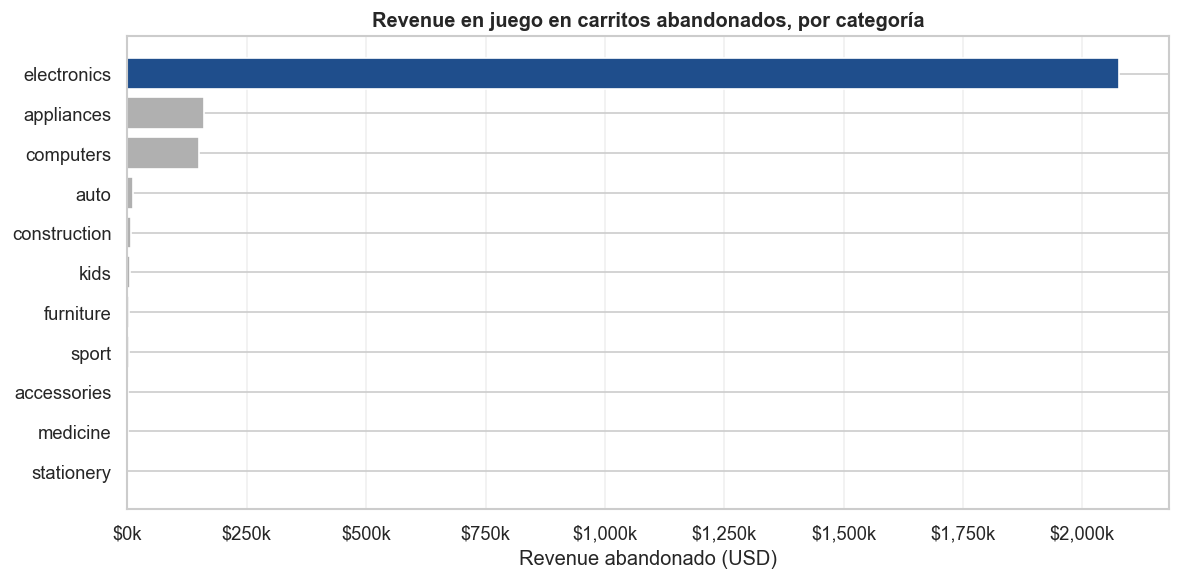

In [45]:
# ── FASE II · ANTES: versión EXPLORATORIA del héroe (reproduce 4.8a) ──
# Reusa `prize` y `top_cat` de 4.8a (revenue en juego por categoría, por unidad).
pr = prize.sort_values('revenue_en_juego')
col0 = ['#1f4e8c' if c == top_cat else '#b0b0b0' for c in pr.index]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(pr.index, pr['revenue_en_juego'], color=col0, edgecolor='white')
ax.set_title('Revenue en juego en carritos abandonados, por categoría', fontweight='bold')
ax.set_xlabel('Revenue abandonado (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:,.0f}k'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

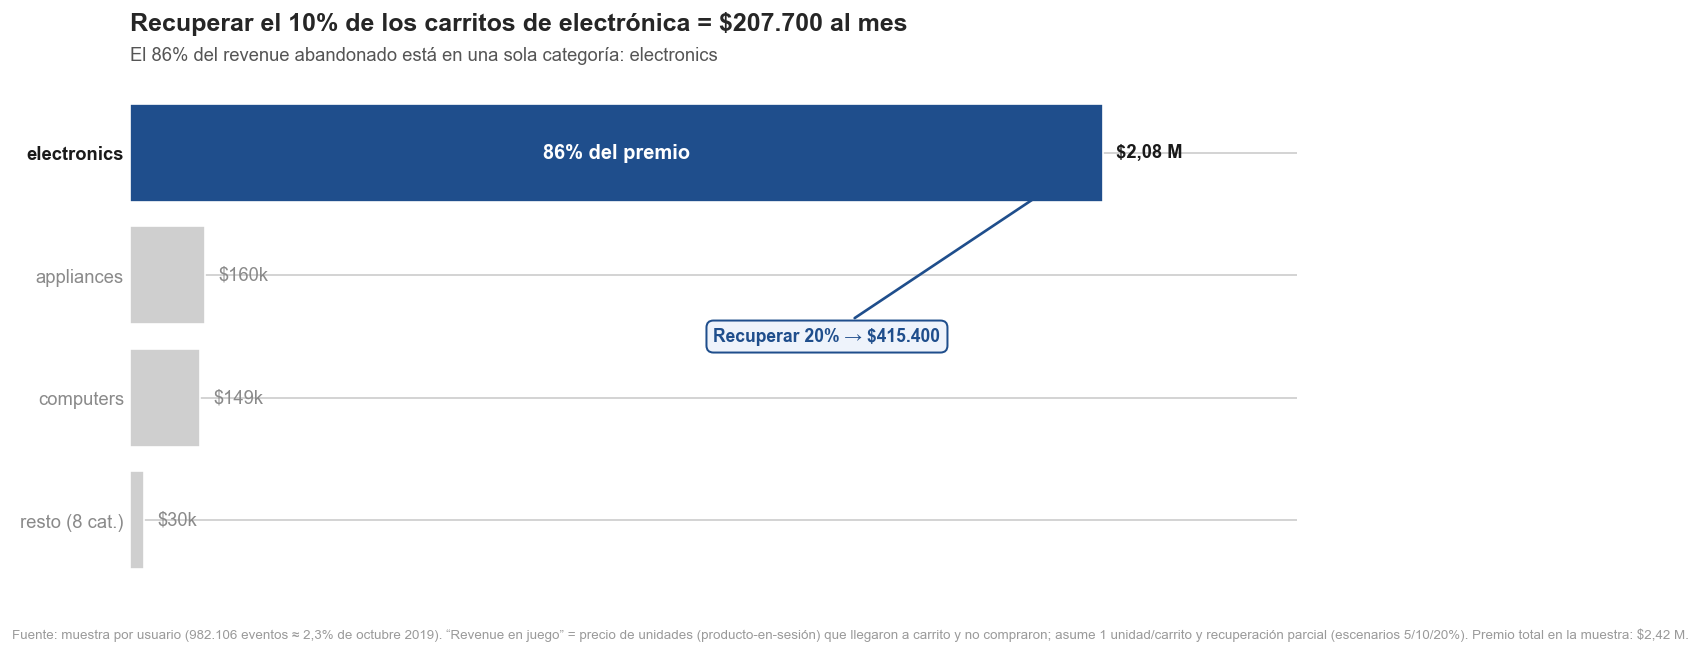

In [46]:
# ── FASE II · DESPUÉS: versión ACLARATORIA del héroe (Palanca A) ──
# Reusa `prize` y `top_cat` de 4.8a.
def _money(v):
    return f"${v/1e6:.2f} M".replace('.', ',') if v >= 1e6 else f"${v/1e3:.0f}k"
def _money_full(v):
    return f"${v:,.0f}".replace(',', '.')

total_prize = prize['revenue_en_juego'].sum()
elec_prize  = prize.loc[top_cat, 'revenue_en_juego']
pct_elec    = elec_prize / total_prize
rec10, rec20 = elec_prize * 0.10, elec_prize * 0.20

# Data-to-Ink: top-3 categorías + resto colapsado (no compite por la mirada)
top3  = prize.head(3)['revenue_en_juego']
resto = prize.iloc[3:]['revenue_en_juego']
acl = top3.copy()
if len(resto):
    acl[f"resto ({len(resto)} cat.)"] = resto.sum()
acl = acl.sort_values()                      # mayor arriba en barh

ACCENT, GREY = '#1f4e8c', '#cfcfcf'
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.barh(acl.index, acl.values, color=[ACCENT if c == top_cat else GREY for c in acl.index])

# Etiquetas $ directas (permiten eliminar el eje X) + callout 82% en la barra clave
for y, (cat, val) in enumerate(acl.items()):
    ax.text(val + total_prize * 0.012, y, _money(val), va='center', fontsize=11,
            fontweight='bold' if cat == top_cat else 'normal',
            color='#1a1a1a' if cat == top_cat else '#8a8a8a')
yi = list(acl.index).index(top_cat)
ax.text(elec_prize * 0.5, yi, f"{pct_elec:.0%} del premio", va='center', ha='center',
        color='white', fontweight='bold', fontsize=12)

# Data-to-Ink: fuera eje X, spines y grid; resaltar solo la etiqueta clave
ax.set_xlim(0, elec_prize * 1.2)
ax.xaxis.set_visible(False)
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(axis='y', length=0)
for lbl in ax.get_yticklabels():
    if lbl.get_text() == top_cat:
        lbl.set_fontweight('bold'); lbl.set_color('#1a1a1a')
    else:
        lbl.set_color('#8a8a8a')

# Jerarquía + acto de habla directivo: título-acción y subtítulo de contexto
ax.set_title(f"Recuperar el 10% de los carritos de electrónica = {_money_full(rec10)} al mes",
             fontsize=15, fontweight='bold', loc='left', pad=30)
ax.annotate(f"El {pct_elec:.0%} del revenue abandonado está en una sola categoría: {top_cat}",
            xy=(0, 1.04), xycoords='axes fraction', fontsize=11, color='#555')

# Recorrido visual: anotación que lleva la mirada del premio a la acción
ax.annotate(f"Recuperar 20% → {_money_full(rec20)}",
            xy=(elec_prize, yi), xytext=(elec_prize * 0.60, yi - 1.5),
            fontsize=10.5, color=ACCENT, fontweight='bold', ha='left', va='center',
            arrowprops=dict(arrowstyle='->', color=ACCENT, lw=1.6),
            bbox=dict(boxstyle='round,pad=0.4', fc='#eef3fb', ec=ACCENT, lw=1.2))

fig.text(0.01, -0.04,
    "Fuente: muestra por usuario (982.106 eventos ≈ 2,3% de octubre 2019). “Revenue en juego” = precio de "
    "unidades (producto-en-sesión) que llegaron a carrito y no compraron; asume 1 unidad/carrito y "
    f"recuperación parcial (escenarios 5/10/20%). Premio total en la muestra: {_money(total_prize)}.",
    fontsize=8, color='#9a9a9a')
plt.tight_layout()
plt.savefig(config.FIGURES / 'aclaratorio_01_revenue_electronics.png', bbox_inches='tight', dpi=120)
plt.show()

### De exploratorio a aclaratorio — justificación de las decisiones visuales

La versión exploratoria (arriba) es correcta para el analista, pero obliga a *leer* el gráfico: recorrer el eje, comparar las 10 categorías y deducir la conclusión. La versión aclaratoria está diseñada para **convencer y motivar una acción** (acto de habla directivo) de un vistazo.

| Decisión de diseño | Principio del curso | Antes (exploratoria) → Después (aclaratoria) |
|---|---|---|
| **Título-acción** con verbo y cifra ("Recuperar el 10% … = \$207.700") | Acto de habla directivo · llamada a la acción (5ª capa del argumento) | Título descriptivo ("Revenue en juego…") → título que dice **qué hacer y cuánto vale** |
| **Color solo en electronics**, resto en gris | Atributos preatentivos · contraste (gris = contexto, color = dato clave) | Ya presente; se mantiene y refuerza |
| **Eliminar eje X y grilla**; etiquetas de \$ directas sobre la barra | Data-to-Ink · "menos es más" | Eje en \$k + grilla → **cero tinta no informativa**; el dato se lee en la barra |
| **Colapsar la cola** en "resto (N cat.)" | Data-to-Ink · una gráfica, un mensaje | 10 categorías compitiendo → 3 + resto; la mirada no se dispersa |
| **Callout "82% del premio"** dentro de la barra | Jerarquía · anotación que revela el mensaje | El lector deducía la concentración → se le **dice** |
| **Anotación con flecha** al escenario de recuperación (20% → \$415.400) | Recorrido visual (rompe el patrón Z) · storytelling integrado | Sin acción visible → la mirada va del premio a **la palanca** |
| **Subtítulo de contexto** ("el 82% está en una sola categoría") | Anatomía del argumento: contexto + patrón | — (la conclusión quedaba implícita) |
| **Barras ordenadas por valor** | Balance · reduce fricción de lectura | Se mantiene |

**Patrón Contexto → Hallazgo → Traducción de negocio → Acción:**
- **Contexto:** el negocio pierde ventas en el carrito (abandono real 32,4%).
- **Hallazgo:** el 82% del revenue abandonado (\$2,08 M de \$2,53 M) está en **electronics**.
- **Traducción:** recuperar incluso una fracción modesta vale seis cifras (10% = \$207.700; 20% = \$415.400) **sobre una muestra del 2,3% de octubre** → a escala completa, ~40× más.
- **Acción:** priorizar la recuperación de carritos de electrónica con incentivo inmediato/en pantalla en la franja matutina (ver H3 y H7).

**Prueba de los 30 segundos:** el título dice la acción y el dinero; el color lleva la mirada a electronics; la anotación cuantifica la palanca. El gerente decide *"recuperar carritos de electrónica"* sin leer el eje.

### ⏳ Tareas pendientes para el equipo (Fase II)

Este bloque deja **andamiaje funcional**, no la versión final. Siguiendo las instrucciones del taller (Data-to-Ink, preatentivos, jerarquía, Gestalt, anotaciones, acto de habla), quedan dos frentes abiertos:

**1. Pulir el gráfico héroe (estética).** La versión aclaratoria es un borrador en matplotlib. Mejoras sugeridas:
- Migrar a **Plotly** (`go.Figure`): el curso lo asocia al aclaratorio y alimenta directo el dashboard (Fase III).
- Tipografía y paleta institucional coherentes; afinar la posición de anotaciones y etiquetas; valorar un *callout* de un solo número grande para el premio.

**2. No limitarnos a un solo gráfico.** La tesis es "una historia, **dos** momentos" (D2) y el dashboard responde **tres** preguntas (PN1–PN3). Conviene una comparativa exploratorio→aclaratorio para cada ancla:

| Ancla | Gráfico candidato | Estado |
|---|---|---|
| **PN1 · Palanca A (conversión)** | Revenue en juego en electronics (este) | Borrador |
| **PN2 · Palanca B (retención)** | Concentración de valor: 31,7% recurrentes = 69% del revenue (4.6) + timing de recompra (4.8b) | Pendiente |
| **PN3 · Cuándo/con qué** | Intensidad horaria: la mañana convierte ~2× (4.3) | Pendiente |

> Cada gráfica final debe pasar la prueba de 30 s y seguir el patrón Contexto → Hallazgo → Traducción de negocio → Acción.